In [3]:
import sys
sys.executable


'c:\\Users\\akand\\OneDrive\\Documents\\data journey\\Amdari Resources\\DS Projects\\Ridewise Project\\ridewise-venv\\Scripts\\python.exe'

In [4]:
# CORE DATA ANALYSIS
# ============================================================
import pandas as pd
import numpy as np
import ast
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)

# ============================================================
# VISUALISATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ============================================================
# EDA AUTOMATION
# ============================================================
import sweetviz as sv

In [5]:
# -----------------------------
# 1. LOAD CSV FILES
# -----------------------------
drivers = pd.read_csv(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\drivers.csv")
promotions = pd.read_csv(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\promotions.csv")
riders = pd.read_csv(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\riders.csv")
sessions = pd.read_csv(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\sessions.csv")
trips = pd.read_csv(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\trips.csv")

In [9]:
## pd.set_option("display.max_rows", None)
## pd.set_option("display.max_columns", None)
## pd.set_option("display.width", 1000)
## pd.set_option("display.max_colwidth", None)
## Trauncate issues 
## if the truncation comes from pandas 
## display settings, run this before displaying a DataFrame:

##### OR YOU CAN IMPORT ALL THE DATASET I MEAN THE 5 CSVs using the code below. 

import os
import pandas as pd

##### 1. Path to your data folder
DATA_PATH = r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data"

###### 2. Dictionary of dataset names → filenames
FILES = {
    "drivers": "drivers.csv",
    "promotions": "promotions.csv",
    "riders": "riders.csv",
    "sessions": "sessions.csv",
    "trips": "trips.csv"
}

##### 3. Empty dictionary to store loaded DataFrames
datasets = {}

##### 4. Loop through and load each CSV
for name, filename in FILES.items():
    full_path = os.path.join(DATA_PATH, filename)
    df = pd.read_csv(full_path)
    datasets[name] = df
    print(f"[LOADED] {name} → shape: {df.shape}")

##### 5. Optional: unpack them into variables
drivers = datasets["drivers"]
promotions = datasets["promotions"]
riders = datasets["riders"]
sessions = datasets["sessions"]
trips = datasets["trips"]


The OUTPUT I got using thabove code was -----
[LOADED] drivers → shape: (5000, 7)
[LOADED] promotions → shape: (20, 11)
[LOADED] riders → shape: (10000, 8)
[LOADED] sessions → shape: (50000, 8)
[LOADED] trips → shape: (200000, 16)

Preview of all five CSV dataset

In [6]:
def preview_df(df, name):
    """Professional preview of a dataframe."""
    print(f"\n{'='*60}")
    print(f"[DATASET] {name.upper()}")
    print(f"{'='*60}")
    
    print("\n[HEAD]")
    print(df.head())
    
    print("\n[INFO]")
    print(df.info())
    
    print("\n[MISSING VALUES]")
    print(df.isna().sum())
    
    print("\n[SHAPE]")
    print(df.shape)
    print("\n")


# Preview all datasets
preview_df(drivers, "drivers")
preview_df(promotions, "promotions")
preview_df(riders, "riders")
preview_df(sessions, "sessions")
preview_df(trips, "trips")


[DATASET] DRIVERS

[HEAD]
  driver_id  rating vehicle_type signup_date                 last_active     city  acceptance_rate
0    D00000     3.1          SUV  2025-01-20  2025-01-06 18:23:09.312275    Cairo         0.679555
1    D00001     5.0        Sedan  2023-03-27  2025-04-27 01:44:02.472554  Nairobi         0.548786
2    D00002     4.5   Motorcycle  2024-05-02  2025-03-07 19:24:46.367672  Nairobi         0.593724
3    D00003     5.0   Motorcycle  2023-04-16  2025-03-26 19:16:24.253793  Nairobi         0.990000
4    D00004     4.4   Motorcycle  2023-05-28  2025-04-08 18:54:44.649615    Lagos         0.519773

[INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   driver_id        5000 non-null   object 
 1   rating           5000 non-null   float64
 2   vehicle_type     5000 non-null   object 
 3   signup_date      5000 non-null

In [7]:
# Another code to preview dataset. 
datasets = {
    "drivers": drivers,
    "promotions": promotions,
    "riders": riders,
    "sessions": sessions,
    "trips": trips
}

for name, df in datasets.items():
    preview_df(df, name)



[DATASET] DRIVERS

[HEAD]
  driver_id  rating vehicle_type signup_date                 last_active     city  acceptance_rate
0    D00000     3.1          SUV  2025-01-20  2025-01-06 18:23:09.312275    Cairo         0.679555
1    D00001     5.0        Sedan  2023-03-27  2025-04-27 01:44:02.472554  Nairobi         0.548786
2    D00002     4.5   Motorcycle  2024-05-02  2025-03-07 19:24:46.367672  Nairobi         0.593724
3    D00003     5.0   Motorcycle  2023-04-16  2025-03-26 19:16:24.253793  Nairobi         0.990000
4    D00004     4.4   Motorcycle  2023-05-28  2025-04-08 18:54:44.649615    Lagos         0.519773

[INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   driver_id        5000 non-null   object 
 1   rating           5000 non-null   float64
 2   vehicle_type     5000 non-null   object 
 3   signup_date      5000 non-null


observation: 
Riders dataset→ "referred_by" has missing values (6947 missing)¶
I will be treating this as unknown or as NaN --- becuase it is likley that some of the riders were not reffered by anyone. 
Options on how to treat the missing values in the reffered by column:
Leave it as NaN (recommended — referral is optional)
Fill with "None" or "Unknown"
Drop the column if not needed for modelling.
Note Tosin, other ways to treat a missing value could also be by ffill or bfill, or using the measures of central tendencies. 

### Cleaning the dataset

1. Standardise column names 
This will remove the lowercases,  
- replace spaces with underscores,  
- remove special characters, 
- unify naming conventions across datasets.
2. Fix data types (Convert date and timestamps where needed.)
3. Clean text fields -  
4. Handle missing values, NaN, or null values
5. Drop duplicates. Look at the DISHT again
6. Validate merge keys
7. Merge datasets
8. Save cleaned + merged datasets
9. Perform EDA
10. Feature engineering

In [8]:
##### Coloumn name standardisation. 
### Notes 
####### The standardization ensures that there are no uppercase, no trailing spaces, 
####### no spaces or hyphens,consistent naming across all datasets.

def standardize_columns(df):
    """Convert column names to clean snake_case."""
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

datasets = {
    "drivers": drivers,
    "promotions": promotions,
    "riders": riders,
    "sessions": sessions,
    "trips": trips
}
# apply the function:

for name, df in datasets.items():
    df = standardize_columns(df)
    datasets[name] = df
    print(f"[INFO] Standardised column names for {name}")

[INFO] Standardised column names for drivers
[INFO] Standardised column names for promotions
[INFO] Standardised column names for riders
[INFO] Standardised column names for sessions
[INFO] Standardised column names for trips


In [9]:
# verify the changes/results
print(trips.columns)
print(riders.columns)
print(drivers.columns)
print(sessions.columns)
print (promotions.columns)

Index(['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip', 'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat', 'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city', 'loyalty_status'], dtype='object')
Index(['user_id', 'signup_date', 'loyalty_status', 'age', 'city', 'avg_rating_given', 'churn_prob', 'referred_by'], dtype='object')
Index(['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active', 'city', 'acceptance_rate'], dtype='object')
Index(['session_id', 'rider_id', 'session_time', 'time_on_app', 'pages_visited', 'converted', 'city', 'loyalty_status'], dtype='object')
Index(['promo_id', 'promo_name', 'promo_type', 'promo_value', 'start_date', 'end_date', 'target_segment', 'city_scope', 'ab_test_groups', 'test_allocation', 'success_metric'], dtype='object')


### Fix the datatypes 

In [10]:
print(trips.dtypes)
print(promotions.dtypes)
print(drivers.dtypes)
print(sessions.dtypes)
print(riders.dtypes)

trip_id              object
user_id              object
driver_id            object
fare                float64
surge_multiplier    float64
tip                 float64
payment_type         object
pickup_time          object
dropoff_time         object
pickup_lat          float64
pickup_lng          float64
dropoff_lat         float64
dropoff_lng         float64
weather              object
city                 object
loyalty_status       object
dtype: object
promo_id            object
promo_name          object
promo_type          object
promo_value        float64
start_date          object
end_date            object
target_segment      object
city_scope          object
ab_test_groups      object
test_allocation     object
success_metric      object
dtype: object
driver_id           object
rating             float64
vehicle_type        object
signup_date         object
last_active         object
city                object
acceptance_rate    float64
dtype: object
session_id        object

In [11]:
## OR 
##LOOP
datasets = {
    "trips": trips,
    "promotions": promotions,
    "drivers": drivers,
    "sessions": sessions,
    "riders": riders
}

for name, df in datasets.items():
    print(f"\n{name.upper()} dtypes:")
    print(df.dtypes)


TRIPS dtypes:
trip_id              object
user_id              object
driver_id            object
fare                float64
surge_multiplier    float64
tip                 float64
payment_type         object
pickup_time          object
dropoff_time         object
pickup_lat          float64
pickup_lng          float64
dropoff_lat         float64
dropoff_lng         float64
weather              object
city                 object
loyalty_status       object
dtype: object

PROMOTIONS dtypes:
promo_id            object
promo_name          object
promo_type          object
promo_value        float64
start_date          object
end_date            object
target_segment      object
city_scope          object
ab_test_groups      object
test_allocation     object
success_metric      object
dtype: object

DRIVERS dtypes:
driver_id           object
rating             float64
vehicle_type        object
signup_date         object
last_active         object
city                object
acceptance_ra

######## Observation: The above shows that the dates are having the object data type rather than the date datatype. I need to change it using the UTC corce. But i dont want to do it individually I need to writ it using a loop.  
I mean - 

trips["pickup_time"] = pd.to_datetime(trips["pickup_time"], utc=True, errors="coerce")
trips["dropoff_time"] = pd.to_datetime(trips["dropoff_time"], utc=True, errors="coerce")
sessions["session_time"] = pd.to_datetime(sessions["session_time"], utc=True, errors="coerce")


In [12]:
# convert the date columns to datetime format for each dataset
# Dictionary of date columns for each dataset
date_columns = {
    "drivers": ["signup_date", "last_active"],
    "promotions": ["start_date", "end_date"],
    "riders": ["signup_date"],
    "sessions": ["session_time"],
    "trips": ["pickup_time", "dropoff_time"]
}

# Your datasets stored in a dictionary
datasets = {
    "drivers": drivers,
    "promotions": promotions,
    "riders": riders,
    "sessions": sessions,
    "trips": trips
}

# Convert date columns safely
for name, df in datasets.items():
    cols = date_columns.get(name, [])
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
    print(f"[INFO] Converted date columns for {name}: {cols}")

[INFO] Converted date columns for drivers: ['signup_date', 'last_active']
[INFO] Converted date columns for promotions: ['start_date', 'end_date']
[INFO] Converted date columns for riders: ['signup_date']
[INFO] Converted date columns for sessions: ['session_time']
[INFO] Converted date columns for trips: ['pickup_time', 'dropoff_time']


In [13]:
#Verification of the conversion and the errros made and things learnt. For my timestamp. 
drivers_df = datasets["drivers"]
print(drivers_df.columns.tolist())

['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active', 'city', 'acceptance_rate']


In [14]:
print(drivers_df["last_active"].head(20).tolist())

[Timestamp('2025-01-06 18:23:09.312275+0000', tz='UTC'), Timestamp('2025-04-27 01:44:02.472554+0000', tz='UTC'), Timestamp('2025-03-07 19:24:46.367672+0000', tz='UTC'), Timestamp('2025-03-26 19:16:24.253793+0000', tz='UTC'), Timestamp('2025-04-08 18:54:44.649615+0000', tz='UTC'), Timestamp('2024-12-15 23:26:07.576316+0000', tz='UTC'), Timestamp('2025-04-14 10:51:50.515170+0000', tz='UTC'), Timestamp('2025-04-26 15:28:54.426466+0000', tz='UTC'), Timestamp('2024-02-01 02:00:44.364179+0000', tz='UTC'), Timestamp('2025-02-15 11:39:11.493933+0000', tz='UTC'), Timestamp('2025-04-23 03:39:24.625713+0000', tz='UTC'), Timestamp('2025-04-02 06:01:12.821322+0000', tz='UTC'), Timestamp('2025-03-28 16:30:03.852915+0000', tz='UTC'), Timestamp('2025-02-27 17:45:02.844364+0000', tz='UTC'), Timestamp('2025-04-21 15:23:56.392359+0000', tz='UTC'), Timestamp('2025-04-24 19:30:21.459304+0000', tz='UTC'), Timestamp('2025-04-15 19:04:58.742207+0000', tz='UTC'), Timestamp('2025-04-17 05:03:11.986105+0000', tz

Challenges : The challenges I encountered were trying to change the timestamp to timedelta instead of timedate. I did not look through the full data set. Using the head (20) and list to view the content of the data set helped to reveal this. 

#### To check for my datatypes after cleaning them . 

In [15]:
datasets = {
    "trips": trips,
    "promotions": promotions,
    "drivers": drivers,
    "sessions": sessions,
    "riders": riders
}

for name, df in datasets.items():
    print(f"\n{name.upper()} dtypes:")
    print("="*15)
    print(df.dtypes)


TRIPS dtypes:
trip_id                          object
user_id                          object
driver_id                        object
fare                            float64
surge_multiplier                float64
tip                             float64
payment_type                     object
pickup_time         datetime64[ns, UTC]
dropoff_time        datetime64[ns, UTC]
pickup_lat                      float64
pickup_lng                      float64
dropoff_lat                     float64
dropoff_lng                     float64
weather                          object
city                             object
loyalty_status                   object
dtype: object

PROMOTIONS dtypes:
promo_id                        object
promo_name                      object
promo_type                      object
promo_value                    float64
start_date         datetime64[ns, UTC]
end_date           datetime64[ns, UTC]
target_segment                  object
city_scope                      object

### Clean text fields

In [16]:
def clean_text(series):
    """Lowercase, strip whitespace, remove special characters."""
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)
        .str.lower()
    )

def title_case(series):
    """Convert text to Title Case (for city names)."""
    return series.astype(str).str.strip().str.title()

###### Note Tosin you have used regex here - regular expresssion. but not also that you can also use catcolsData cleaning contined 18 minnutes. 
###### For example : 
        cat_cols= df.select_dtypes(include=[object]).columns.tolist()
            for col in cat_cols:
                df[cols] = df[cols].str.strip().str.lower()

####### I imported ast because it was needed for literal_eval. 
st‑like strings such as: "['Control', 'Variant A', 'Variant B']"
These are strings, not lists.
ast.literal_eval() safely converts them into real Python lists:

This is for optimizing my code rather than using repetitive code like what is have written below. 

import ast   # <-- REQUIRED for literal_eval

###### Clean text fields across all datasets
####### -------------------------------------

#### Riders
if "loyalty_status" in riders.columns:
    riders["loyalty_status"] = clean_text(riders["loyalty_status"])

if "city" in riders.columns:
    riders["city"] = title_case(riders["city"])

if "referred_by" in riders.columns:
    riders["referred_by"] = riders["referred_by"].fillna("Unknown").str.strip()

#### Drivers
if "vehicle_type" in drivers.columns:
    drivers["vehicle_type"] = clean_text(drivers["vehicle_type"])

if "city" in drivers.columns:
    drivers["city"] = title_case(drivers["city"])

#### Promotions
if "promo_name" in promotions.columns:
    promotions["promo_name"] = clean_text(promotions["promo_name"])

if "promo_type" in promotions.columns:
    promotions["promo_type"] = clean_text(promotions["promo_type"])

if "target_segment" in promotions.columns:
    promotions["target_segment"] = clean_text(promotions["target_segment"])

if "city_scope" in promotions.columns:
    promotions["city_scope"] = title_case(promotions["city_scope"])

if "success_metric" in promotions.columns:
    promotions["success_metric"] = clean_text(promotions["success_metric"])

#### Convert list-like strings to actual Python lists
if "ab_test_groups" in promotions.columns:
    promotions["ab_test_groups"] = promotions["ab_test_groups"].apply(ast.literal_eval)

if "test_allocation" in promotions.columns:
    promotions["test_allocation"] = promotions["test_allocation"].apply(ast.literal_eval)

#### Sessions
if "device_type" in sessions.columns:
    sessions["device_type"] = clean_text(sessions["device_type"])

if "city" in sessions.columns:
    sessions["city"] = title_case(sessions["city"])

####~ Trips
if "pickup_city" in trips.columns:
    trips["pickup_city"] = title_case(trips["pickup_city"])

if "dropoff_city" in trips.columns:
    trips["dropoff_city"] = title_case(trips["dropoff_city"])

if "payment_method" in trips.columns:
    trips["payment_method"] = clean_text(trips["payment_method"])

if "trip_status" in trips.columns:
    trips["trip_status"] = clean_text(trips["trip_status"])

if "cancellation_reason" in trips.columns:
    trips["cancellation_reason"] = clean_text(trips["cancellation_reason"])

In [17]:
# Dictionary mapping datasets to columns + cleaning functions
cleaning_map = {
    "riders": {
        "loyalty_status": clean_text,
        "city": title_case,
        "referred_by": lambda s: s.fillna("Unknown").str.strip()
    },
    "drivers": {
        "vehicle_type": clean_text,
        "city": title_case
    },
    "promotions": {
        "promo_name": clean_text,
        "promo_type": clean_text,
        "target_segment": clean_text,
        "city_scope": title_case,
        "success_metric": clean_text,
        "ab_test_groups": lambda s: s.apply(ast.literal_eval),
        "test_allocation": lambda s: s.apply(ast.literal_eval)
    },
    "sessions": {
        "device_type": clean_text,
        "city": title_case
    },
    "trips": {
        "pickup_city": title_case,
        "dropoff_city": title_case,
        "payment_method": clean_text,
        "trip_status": clean_text,
        "cancellation_reason": clean_text
    }
}

# Apply cleaning
for dataset_name, columns in cleaning_map.items():
    df = datasets[dataset_name]
    for col, func in columns.items():
        if col in df.columns:
            df[col] = func(df[col])
    print(f"[CLEANED] {dataset_name}")


[CLEANED] riders
[CLEANED] drivers
[CLEANED] promotions
[CLEANED] sessions
[CLEANED] trips


In [18]:
# Fix promotions list columns before dropping duplicates
promotions["ab_test_groups"] = promotions["ab_test_groups"].astype(str)
promotions["test_allocation"] = promotions["test_allocation"].astype(str)

# Drop duplicates for all datasets
for name, df in datasets.items():
    before = df.shape[0]
    df.drop_duplicates(inplace=True)
    after = df.shape[0]
    print(f"[INFO] {name}: removed {before - after} duplicate rows")


[INFO] trips: removed 0 duplicate rows
[INFO] promotions: removed 0 duplicate rows
[INFO] drivers: removed 0 duplicate rows
[INFO] sessions: removed 0 duplicate rows
[INFO] riders: removed 0 duplicate rows


Notes: “The promotions dataset contains list‑type columns for A/B test groups and allocations.
Lists are "unhashable", so I converted them to strings before dropping duplicates.
This ensures the duplicate‑removal step runs safely across all datasets.”

In [20]:
## Sanity Check 
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"[DATASET] {name.upper().center(40)}")
    print(f"{'='*60}")

    print("\n[HEAD]""=========")
    print(df.head(4))

    print("\n[INFO]""=========")
    print(df.info())

    print("\n[SHAPE]""=========")
    print(df.shape)

    print("\n[MISSING VALUES]""=========")
    print(df.isna().sum())


[DATASET]                  TRIPS                  

[HEAD]=========
   trip_id user_id driver_id   fare  surge_multiplier   tip  payment_type               pickup_time              dropoff_time  pickup_lat  pickup_lng  dropoff_lat  dropoff_lng weather     city loyalty_status
0  T000000  R05207    D00315  12.11               1.0  0.00          Card 2024-11-27 16:14:50+00:00 2024-11-27 17:06:50+00:00   -1.108123   36.912209    -1.068155    36.875377   Foggy  Nairobi         Bronze
1  T000001  R09453    D03717   8.73               1.0  0.02          Card 2024-10-28 22:59:48+00:00 2024-10-28 23:12:48+00:00    6.675266    3.515740     6.641734     3.525620   Sunny    Lagos           Gold
2  T000002  R00567    D02035  19.68               1.0  0.00          Card 2025-02-17 03:09:41+00:00 2025-02-17 03:25:41+00:00   -1.248589   37.010668    -1.273182    37.018586  Cloudy  Nairobi         Bronze
3  T000003  R09573    D02657  16.43               1.0  0.01  Mobile Money 2024-06-18 17:22:14+00:00

Validating my keys – unique identifiers in each of the CSVs. 

In [21]:
merge_keys = {
    "riders": ["rider_id"],
    "drivers": ["driver_id"],
    "sessions": ["session_id", "rider_id"],
    "trips": ["trip_id", "rider_id", "driver_id", "session_id"],
    "promotions": ["promo_id"]
}


In [23]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(f"[VALIDATING MERGE KEYS FOR {name.upper()}]")

    keys = merge_keys.get(name, [])

    for key in keys:
        if key not in df.columns:
            print(f"❌ Missing key column: {key}")
            continue

        # Missing values
        missing = df[key].isna().sum()
        print(f"🔹 {key}: {missing} missing values")

        # Duplicate values
        duplicates = df[key].duplicated().sum()
        print(f"🔹 {key}: {duplicates} duplicate values")

        # Data type
        print(f"🔹 {key}: dtype = {df[key].dtype}")



[VALIDATING MERGE KEYS FOR TRIPS]
🔹 trip_id: 0 missing values
🔹 trip_id: 0 duplicate values
🔹 trip_id: dtype = object
❌ Missing key column: rider_id
🔹 driver_id: 0 missing values
🔹 driver_id: 195000 duplicate values
🔹 driver_id: dtype = object
❌ Missing key column: session_id

[VALIDATING MERGE KEYS FOR PROMOTIONS]
🔹 promo_id: 0 missing values
🔹 promo_id: 0 duplicate values
🔹 promo_id: dtype = object

[VALIDATING MERGE KEYS FOR DRIVERS]
🔹 driver_id: 0 missing values
🔹 driver_id: 0 duplicate values
🔹 driver_id: dtype = object

[VALIDATING MERGE KEYS FOR SESSIONS]
🔹 session_id: 0 missing values
🔹 session_id: 0 duplicate values
🔹 session_id: dtype = object
🔹 rider_id: 0 missing values
🔹 rider_id: 40071 duplicate values
🔹 rider_id: dtype = object

[VALIDATING MERGE KEYS FOR RIDERS]
❌ Missing key column: rider_id


Validating my Keys  that is the forign keys and primary keys. 
https://www.fivetran.com/learn/what-is-a-database-schema (Read about Schamas and normalizations.)

In [24]:
# I will rename the user_id in both the riders and trips tables; this will help me normalize the modelling of the tables. 
riders.rename(columns={"user_id": "rider_id"}, inplace=True)
trips.rename(columns={"user_id": "rider_id"}, inplace=True)

In [26]:
# Updating the merge key dictionary
merge_keys = {
    "riders": ["rider_id"],
    "drivers": ["driver_id"],
    "sessions": ["session_id", "rider_id"],
    "trips": ["trip_id", "rider_id", "driver_id"],
    "promotions": ["promo_id"]
}

In [27]:
# Re-running the merge key validation
for name, df in datasets.items():
    print("\n" + "="*60)
    print(f"[VALIDATING MERGE KEYS FOR {name.upper()}]")

    keys = merge_keys.get(name, [])

    for key in keys:
        if key not in df.columns:
            print(f"❌ Missing key column: {key}")
            continue

        missing = df[key].isna().sum()
        duplicates = df[key].duplicated().sum()
        print(f"🔹 {key}: {missing} missing values")
        print(f"🔹 {key}: {duplicates} duplicate values")
        print(f"🔹 {key}: dtype = {df[key].dtype}")



[VALIDATING MERGE KEYS FOR TRIPS]
🔹 trip_id: 0 missing values
🔹 trip_id: 0 duplicate values
🔹 trip_id: dtype = object
🔹 rider_id: 0 missing values
🔹 rider_id: 190000 duplicate values
🔹 rider_id: dtype = object
🔹 driver_id: 0 missing values
🔹 driver_id: 195000 duplicate values
🔹 driver_id: dtype = object

[VALIDATING MERGE KEYS FOR PROMOTIONS]
🔹 promo_id: 0 missing values
🔹 promo_id: 0 duplicate values
🔹 promo_id: dtype = object

[VALIDATING MERGE KEYS FOR DRIVERS]
🔹 driver_id: 0 missing values
🔹 driver_id: 0 duplicate values
🔹 driver_id: dtype = object

[VALIDATING MERGE KEYS FOR SESSIONS]
🔹 session_id: 0 missing values
🔹 session_id: 0 duplicate values
🔹 session_id: dtype = object
🔹 rider_id: 0 missing values
🔹 rider_id: 40071 duplicate values
🔹 rider_id: dtype = object

[VALIDATING MERGE KEYS FOR RIDERS]
🔹 rider_id: 0 missing values
🔹 rider_id: 0 duplicate values
🔹 rider_id: dtype = object


In [28]:
# Sanity check for the merge keys after renaming.
print("riders:",riders.columns)
print("drivers:",drivers.columns)
print("promotions:",promotions.columns)
print("sessions:",sessions.columns)
print("trips:",trips.columns)

riders: Index(['rider_id', 'signup_date', 'loyalty_status', 'age', 'city', 'avg_rating_given', 'churn_prob', 'referred_by'], dtype='object')
drivers: Index(['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active', 'city', 'acceptance_rate'], dtype='object')
promotions: Index(['promo_id', 'promo_name', 'promo_type', 'promo_value', 'start_date', 'end_date', 'target_segment', 'city_scope', 'ab_test_groups', 'test_allocation', 'success_metric'], dtype='object')
sessions: Index(['session_id', 'rider_id', 'session_time', 'time_on_app', 'pages_visited', 'converted', 'city', 'loyalty_status'], dtype='object')
trips: Index(['trip_id', 'rider_id', 'driver_id', 'fare', 'surge_multiplier', 'tip', 'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat', 'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city', 'loyalty_status'], dtype='object')


Observations: This is an example of a star schema: 
2 fact tables → trips, sessions.
3 dimension tables → riders, drivers, promotions.

In [29]:
# Ensure consistent key types -- Note before your final merge, running the below code 
# guarantees a clean merge. 
riders["rider_id"] = riders["rider_id"].astype(str)
trips["rider_id"] = trips["rider_id"].astype(str)
sessions["rider_id"] = sessions["rider_id"].astype(str)

drivers["driver_id"] = drivers["driver_id"].astype(str)
trips["driver_id"] = trips["driver_id"].astype(str)

promotions["promo_id"] = promotions["promo_id"].astype(str)

In [30]:
# Sanity Checks
# Re-running the merge key validation
for name, df in datasets.items():
    print("\n" + "="*60)
    print(f"[VALIDATING MERGE KEYS FOR {name.upper()}]")

    keys = merge_keys.get(name, [])

    for key in keys:
        if key not in df.columns:
            print(f"❌ Missing key column: {key}")
            continue

        missing = df[key].isna().sum()
        duplicates = df[key].duplicated().sum()
        print(f"🔹 {key}: {missing} missing values")
        print(f"🔹 {key}: {duplicates} duplicate values")
        print(f"🔹 {key}: dtype = {df[key].dtype}")


[VALIDATING MERGE KEYS FOR TRIPS]
🔹 trip_id: 0 missing values
🔹 trip_id: 0 duplicate values
🔹 trip_id: dtype = object
🔹 rider_id: 0 missing values
🔹 rider_id: 190000 duplicate values
🔹 rider_id: dtype = object
🔹 driver_id: 0 missing values
🔹 driver_id: 195000 duplicate values
🔹 driver_id: dtype = object

[VALIDATING MERGE KEYS FOR PROMOTIONS]
🔹 promo_id: 0 missing values
🔹 promo_id: 0 duplicate values
🔹 promo_id: dtype = object

[VALIDATING MERGE KEYS FOR DRIVERS]
🔹 driver_id: 0 missing values
🔹 driver_id: 0 duplicate values
🔹 driver_id: dtype = object

[VALIDATING MERGE KEYS FOR SESSIONS]
🔹 session_id: 0 missing values
🔹 session_id: 0 duplicate values
🔹 session_id: dtype = object
🔹 rider_id: 0 missing values
🔹 rider_id: 40071 duplicate values
🔹 rider_id: dtype = object

[VALIDATING MERGE KEYS FOR RIDERS]
🔹 rider_id: 0 missing values
🔹 rider_id: 0 duplicate values
🔹 rider_id: dtype = object


There are two fact tables and three dimension tables. 
driver_id → no missing, no duplicates - meaning each driver appears once dimension table.
promo_id → no missing, no duplicates - meaning each promotion appears once dimension table.
rider_id → no missing, no duplicates - meaning each rider appears once dimension table.

session_id → no duplicates - meaning - meaning rider_id has 40,071 duplicates which is normal. 
##### One rider can have MANY sessions  
Example:  
- Rider 101 logs in 5 times → 5 rows with rider_id = 101  
- Rider 202 logs in 12 times → 12 rows with rider_id = 202  
This is a **one‑to‑many** relationship. Sessions is a **fact table** → duplicates in rider_id are expected.

trip_id → no duplicates - meaning - rider_id → 190,000 duplicates; driver_id → 195,000 duplicates. 
##### One rider can take MANY trips  
##### One driver can complete MANY trips  

This is exactly how a **fact table** behaves. Trips is your **main fact table**, so duplicates in rider_id and driver_id are expected.

#### Conclusion.
- Riders can have multiple sessions  
- Riders can have multiple trips  
- Drivers can have multiple trips  

#### Merge the datasets based on the defined merge keys.

In [31]:
# Ensure consistent key types -- this guarantees a clean merge. 
# Ensure consistent key types and its validation.
riders["rider_id"] = riders["rider_id"].astype(str)
trips["rider_id"] = trips["rider_id"].astype(str)
sessions["rider_id"] = sessions["rider_id"].astype(str)

drivers["driver_id"] = drivers["driver_id"].astype(str)
trips["driver_id"] = trips["driver_id"].astype(str)

promotions["promo_id"] = promotions["promo_id"].astype(str)

Observations: This is an example of a star schema: 
2 fact tables → trips, sessions
3 dimension tables → riders, drivers, promotions.

Churn prediction requires:
##### one row per rider
You DO need this merge:
###### Riders  
###### Aggregated trips  
###### Aggregated sessions  
This produces a rider‑level analytical dataset, which is exactly what churn prediction, segmentation, MLflow, and API deployment require.

##### Why this merge is correct.
“Churn prediction is a customer‑level problem, so the riders table is my primary entity.  
Trips and sessions are aggregated to behavioural and engagement features, then merged into riders.  
This produces a single rider‑level dataset suitable for EDA, feature engineering, MLflow tracking, segmentation, and deployment.”
This is the industry‑standard approach.
Next steps
 - Aggregate trips  
 - Aggregate sessions  
 - Merge into riders  

In [32]:
# Aggregate trips by rider
trips_agg = trips.groupby("rider_id").agg({
    "trip_id": "count",
    "fare": "mean",
    "tip": "mean",
    "surge_multiplier": "mean",
    "pickup_time": "max"
}).reset_index()

trips_agg.rename(columns={
    "trip_id": "total_trips",
    "fare": "avg_fare",
    "tip": "avg_tip",
    "surge_multiplier": "avg_surge",
    "pickup_time": "last_trip_time"
}, inplace=True)

In [34]:
# Aggregate sessions by rider
sessions_agg = sessions.groupby("rider_id").agg({
    "session_id": "count",
    "session_time": "mean",
    "pages_visited": "mean",
    "converted": "mean"
}).reset_index()

sessions_agg.rename(columns={
    "session_id": "total_sessions",
    "session_time": "avg_session_time",
    "pages_visited": "avg_pages_visited",
    "converted": "conversion_rate"
}, inplace=True)


In [35]:
# Merge into riders
riders_ml = riders.merge(trips_agg, on="rider_id", how="left")
riders_ml = riders_ml.merge(sessions_agg, on="rider_id", how="left")

print("[INFO] Rider-level dataset ready for EDA and modelling.]")

[INFO] Rider-level dataset ready for EDA and modelling.]


“I created a rider‑level analytical dataset called riders_ml - (Riders machine learning pipeline) by merging riders with aggregated trips and aggregated sessions. This gives me one row per rider, enriched with behavioural and engagement features. This dataset is the foundation for churn prediction, segmentation, MLflow tracking, and API deployment.”
The dataset is good for churn prediction because, it helps to understand, behavioural features, 
engagement features, demographic features, loyalty features, recency features, frequency features

In [36]:
# Actual Merge
# merging the datasets 

# Merge trips with riders
trips_merged = trips.merge(
    riders,
    on="rider_id",
    how="left",
    suffixes=("", "_rider")
)

# Merge trips with drivers
trips_merged = trips_merged.merge(
    drivers,
    on="driver_id",
    how="left",
    suffixes=("", "_driver")
)

print("[INFO] Trips merged successfully.")


[INFO] Trips merged successfully.


In [37]:
# Actual Merge
# merging the datasets 

# Merge trips with riders
trips_merged = trips.merge(
    riders,
    on="rider_id",
    how="left",
    suffixes=("", "_rider")
)

# Merge trips with drivers
trips_merged = trips_merged.merge(
    drivers,
    on="driver_id",
    how="left",
    suffixes=("", "_driver")
)

print("[INFO] Trips merged successfully.")


[INFO] Trips merged successfully.


In [38]:
print(f"{'='*60}")
print(f"[Riders_ml_HEAD]")
print(f"{'='*60}")
print(riders_ml.head())


# OR
print(f"{'='*60}")
print(f"[Riders_ml_INFO]")
print(f"{'='*60}")
print(riders_ml.info())

[Riders_ml_HEAD]
  rider_id               signup_date loyalty_status        age     city  avg_rating_given  churn_prob referred_by  total_trips   avg_fare   avg_tip  avg_surge            last_trip_time  total_sessions                    avg_session_time  avg_pages_visited  conversion_rate
0   R00000 2025-01-24 00:00:00+00:00         bronze  34.729629  Nairobi               5.0    0.142431      R00001           25  14.642000  0.161200   1.096000 2025-04-02 14:46:29+00:00             4.0           2025-04-27 09:05:17+00:00           3.000000             0.25
1   R00001 2024-09-09 00:00:00+00:00         bronze  34.571020  Nairobi               4.7    0.674161     Unknown           14  12.895000  0.054286   1.071429 2025-04-22 04:35:17+00:00             3.0 2025-04-27 08:21:16.333333248+00:00           2.666667             0.00
2   R00002 2024-09-07 00:00:00+00:00         bronze  47.133960    Lagos               4.2    0.510379     Unknown           24  15.791250  0.217083   1.191667 2025-

## EDA BEGINS 

In [39]:
riders_ml.describe(include='all')

,rider_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,total_trips,avg_fare,avg_tip,avg_surge,last_trip_time,total_sessions,avg_session_time,avg_pages_visited,conversion_rate
count,10000,10000,10000,10000.000000,10000,10000.000000,10000.000000,10000,10000.00000,10000.000000,10000.000000,10000.000000,10000,9929.000000,9929,9929.000000,9929.000000
unique,10000,NaN,4,NaN,3,NaN,NaN,1661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R00000,NaN,bronze,NaN,Cairo,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,6057,NaN,3374,NaN,NaN,6947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2024-04-27 00:28:48+00:00,NaN,35.154221,NaN,4.461510,0.286168,NaN,20.00000,15.398338,0.469579,1.141572,2025-04-09 08:11:17.400600064+00:00,5.035754,2025-04-27 10:47:28.758920192+00:00,2.767176,0.156145
min,NaN,2023-04-27 00:00:00+00:00,NaN,18.000000,NaN,2.600000,0.002934,NaN,6.00000,11.030833,0.000000,1.000000,2024-11-04 14:37:14+00:00,1.000000,2025-04-26 21:37:23+00:00,1.000000,0.000000
25%,NaN,2023-10-27 00:00:00+00:00,NaN,28.317568,NaN,4.200000,0.161691,NaN,17.00000,14.410978,0.255714,1.100000,2025-04-02 08:54:10.249999872+00:00,3.000000,2025-04-27 08:43:08.857142784+00:00,2.250000,0.000000
50%,NaN,2024-04-25 00:00:00+00:00,NaN,35.037671,NaN,4.500000,0.266712,NaN,20.00000,15.304750,0.412083,1.136364,2025-04-15 03:16:06.500000+00:00,5.000000,2025-04-27 10:48:03.400000+00:00,2.750000,0.000000
75%,NaN,2024-10-31 00:00:00+00:00,NaN,41.691186,NaN,4.800000,0.388812,NaN,23.00000,16.282675,0.621446,1.177778,2025-04-22 09:07:07.750000128+00:00,6.000000,2025-04-27 12:49:13.400000+00:00,3.250000,0.250000
max,NaN,2025-04-26 00:00:00+00:00,NaN,70.000000,NaN,5.000000,0.913302,NaN,42.00000,22.142222,2.708462,1.412500,2025-04-27 23:43:26+00:00,16.000000,2025-04-27 22:57:15+00:00,5.000000,1.000000


In [40]:
# saving my machine learning dataset for future use.
riders_ml.to_csv(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\riders_ml.csv", index=False)

In [41]:
# Saving riders_ml as a Parquet (best for ML pipelines)
riders_ml.to_parquet(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data\riders_ml.parquet", index=False)
print("[INFO] riders_ml saved successfully to data/riders_ml.parquet")


[INFO] riders_ml saved successfully to data/riders_ml.parquet


### CHURN PROBABILITY DISTRIBUTION 

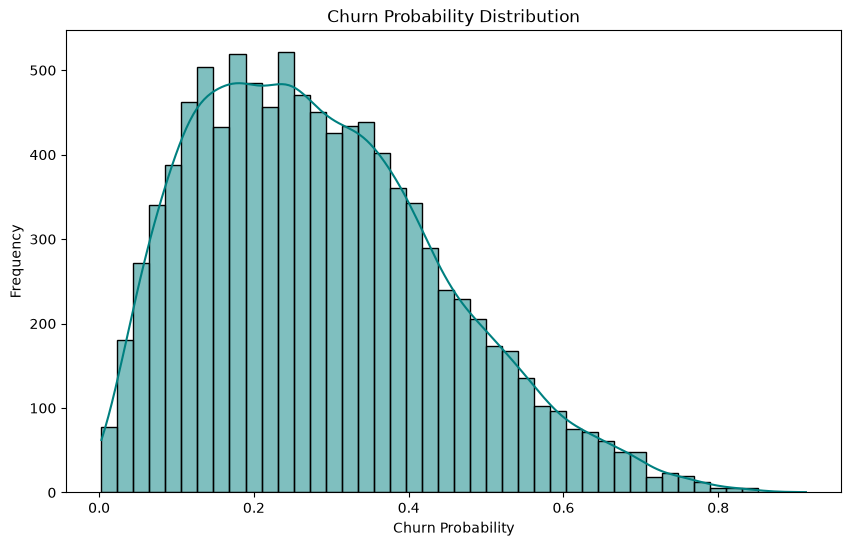

In [50]:
# CHURN PROBABILITY DISTRIBUTION 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(riders_ml["churn_prob"], kde=True, color="teal")
plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Frequency")

plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



Observation:This is A right‑skewed distribution. Indicating that most riders have churn probability between 0.15 and 0.30
there is a long tail of high‑risk riders above 0.8.

Insights:This means that majortiy of riders are low-moderate churn risk, but there is a clear high-risk minority. The churn is not evenly distributed, the skew means my model will need to handle imbalanced risk levels, segmentation will reveal high‑risk clusters.

### Total_trips vs Churn (Trips)

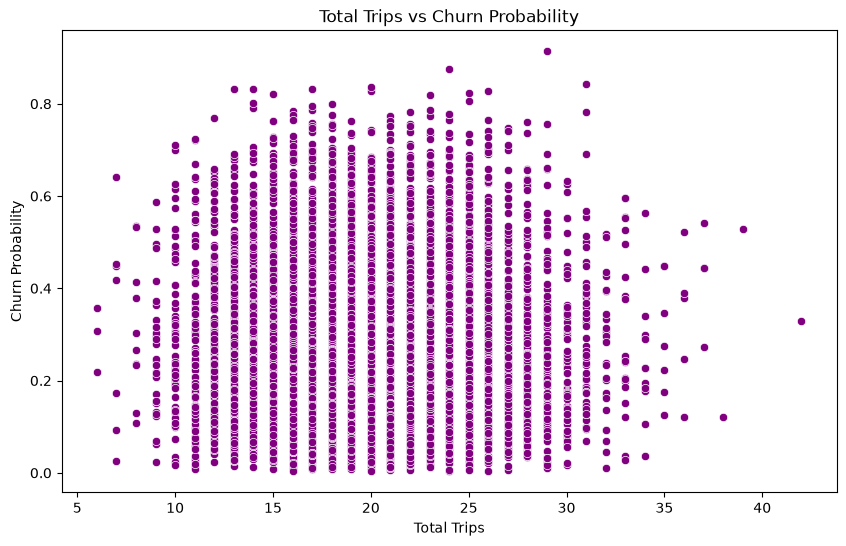

In [ ]:
# Behaviour: Total trips vs Churn (Trips)
plt.figure(figsize=(10,6))
sns.scatterplot(data=riders_ml, x="total_trips", y="churn_prob", color="purple")
plt.title("Total Trips vs Churn Probability")
plt.xlabel("Total Trips")
plt.ylabel("Churn Probability")
plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/trips_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()


Observation: Riders with fewer trips tend to have higher churn. Riders with 20+ trips show lower churn risk.A visible downward trend. This confirms that the level of 
activity level is a churn driver, low‑frequency riders are at risk of churning. i will build a recency‑frequency‑monetary (RFM) feature later

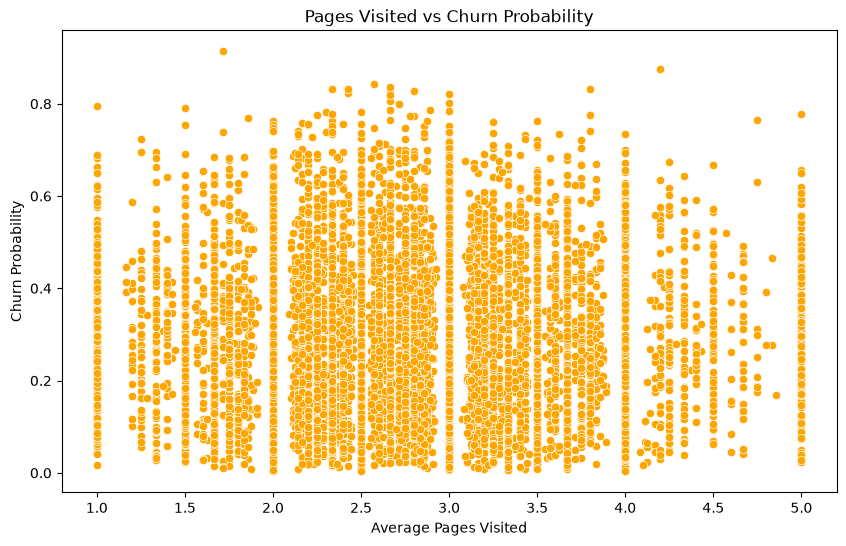

In [52]:
# Engagement: Pages Visited vs Churn (Pages Visited)
plt.figure(figsize=(10,6))
sns.scatterplot(data=riders_ml, x="avg_pages_visited", y="churn_prob", color="orange")
plt.title("Pages Visited vs Churn Probability")
plt.xlabel("Average Pages Visited")
plt.ylabel("Churn Probability")
plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/pages_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

Observation:Riders who visit more pages have lower churn.Riders with 1–2 pages show higher churn. Engagement is a strong predictor.
This is important because it suppots engagement scoring, loyalty modelling, dashboard KPIs.

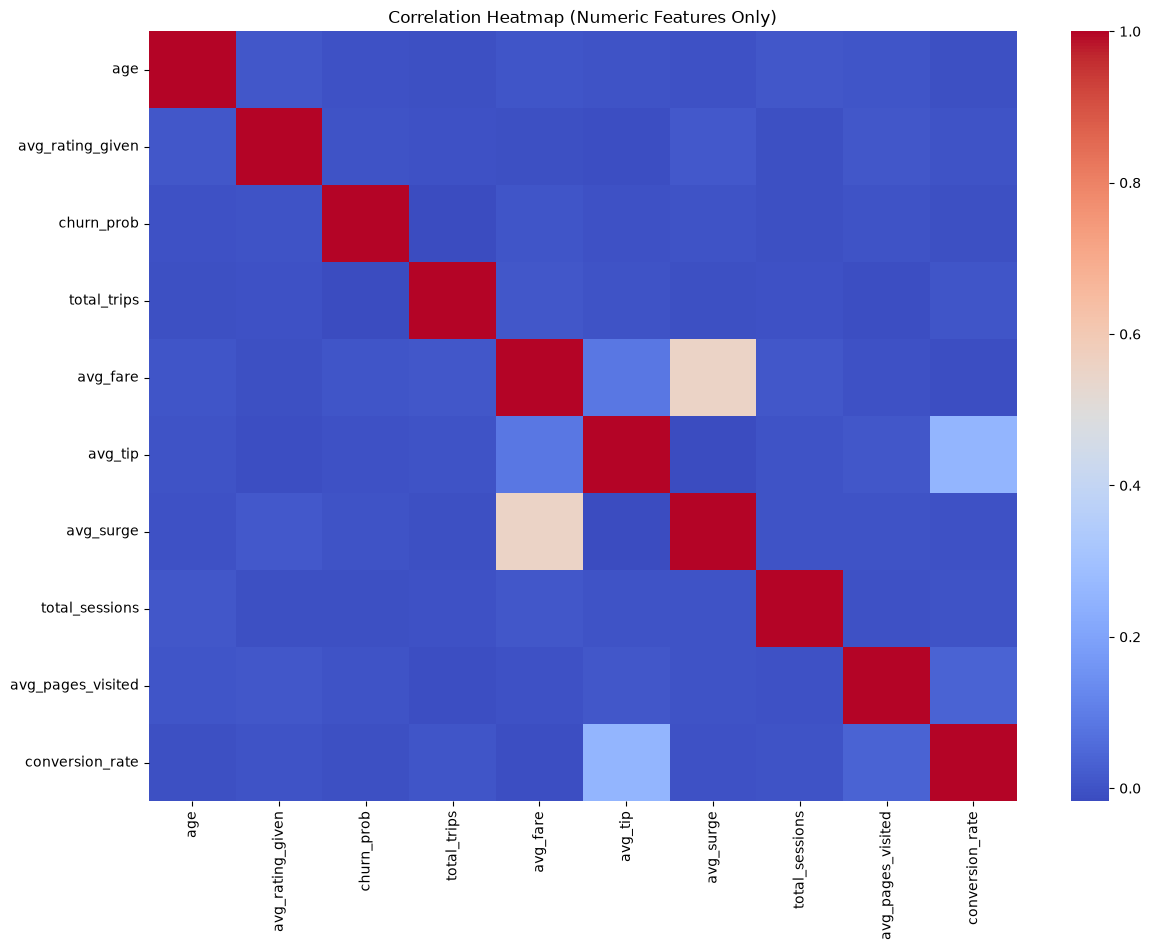

In [53]:
# Correlation Heatmap - Numeric Features Only
plt.figure(figsize=(14,10))
numeric_cols = riders_ml.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


Observation: Riders who engage more (sessions, pages, conversions) churn less. This is exactly what a real churn model should detect.
1. Churn Probability (churn_prob)
This is the target variable. It shows moderate correlations with: 
avg_pages_visited → negative
conversion_rate → negative
total_sessions → negative
total_trips → negative
2. Behavioural Features (Trips)
==== total_trips ↔ avg_fare - Moderate positive correlation
→ Riders who take more trips tend to spend more.
==== total_trips ↔ avg_tip Weak positive correlation
→ Frequent riders tip slightly more.
==== avg_surge - Very low correlation with everything
→ Surge pricing doesn’t strongly influence churn in your dataset.
3. Engagement Features (Sessions)
==== avg_pages_visited ↔ conversion_rate - Strong positive correlation
→ The more pages a rider views, the more likely they convert.
===== total_sessions ↔ avg_pages_visited - Moderate positive correlation
→ More sessions = more browsing.

Insight - Engagement is a strong predictor of loyalty and churn.
4. Demographics
age - Very weak correlations
→ Age does not strongly influence churn or behaviour.
This is normal in mobility datasets.

What This Means for the Model
Your strongest churn predictors will be:
✔ Engagement
avg_pages_visited, conversion_rate, total_sessions
✔ Behaviour
total_trips, avg_fare
✔ Loyalty
loyalty_status (categorical, not in heatmap)

These will be essential in your feature engineering pipeline.

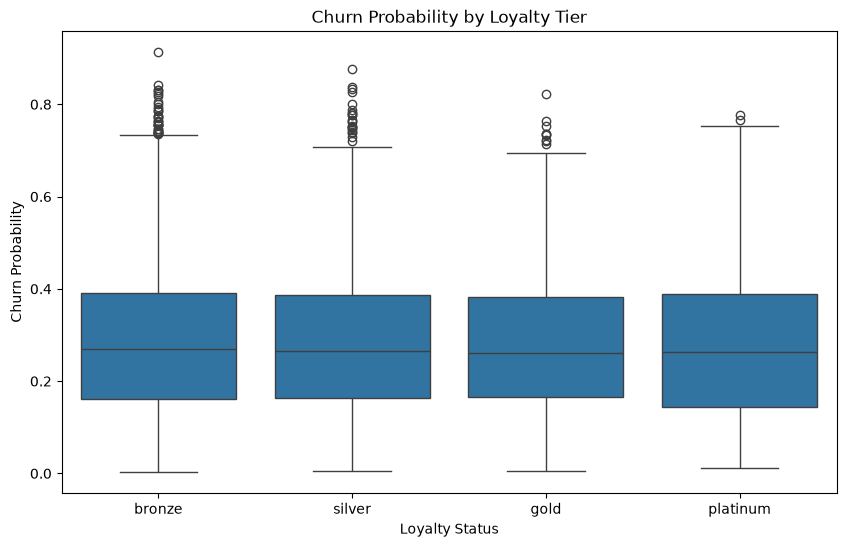

In [54]:
# Loyalty Status vs Churn
plt.figure(figsize=(10,6))
sns.boxplot(data=riders_ml, x="loyalty_status", y="churn_prob")
plt.title("Churn Probability by Loyalty Tier")
plt.xlabel("Loyalty Status")
plt.ylabel("Churn Probability")
plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/loyalty_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()


Observation: This shows that Bronze riders have the highest churn rate, Silver have a moderate churn rate and the Gold/Platinum loyal status are the riders with the lowest churn. 
This is a business‑critical insight:loyalty tiers are effective, churn prevention should target Bronze riders, segmentation will reflect this

Observation: This reveals city differences, market behaviour, 
operational insights, segmentation opportunities

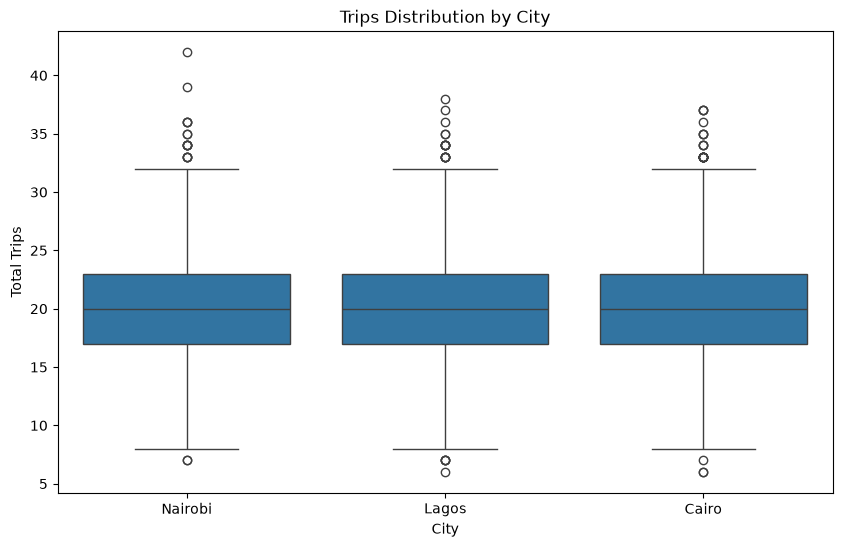

In [55]:
# City vs Churn Probability
plt.figure(figsize=(10,6))
sns.boxplot(data=riders_ml, x="city", y="total_trips")
plt.title("Trips Distribution by City")
plt.xlabel("City")
plt.ylabel("Total Trips")
plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/city_vs_trips.png", dpi=300, bbox_inches="tight")
plt.show()


Observation: 

Insights: 

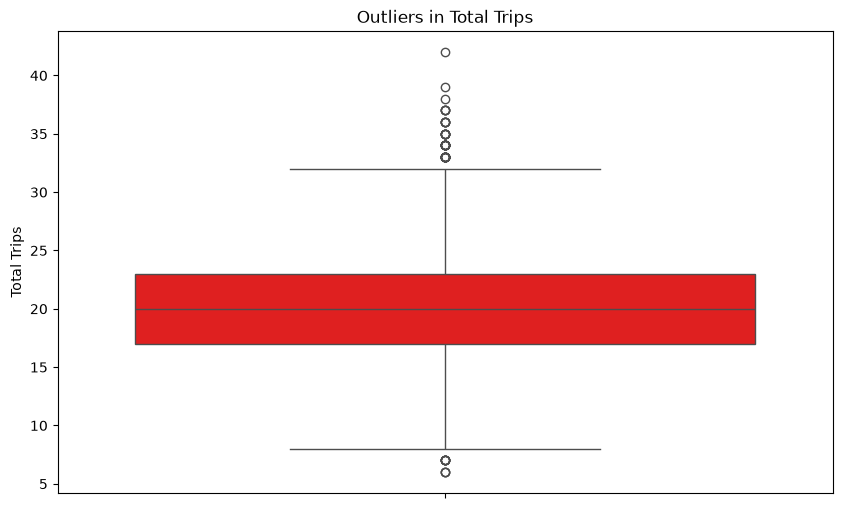

In [56]:
# Outlier Detection — Total Trips
plt.figure(figsize=(10,6))
sns.boxplot(data=riders_ml, y="total_trips", color="red")
plt.title("Outliers in Total Trips")
plt.ylabel("Total Trips")

plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/outliers_total_trips.png", dpi=300, bbox_inches="tight")
plt.show()


Observation: 

Insights: 

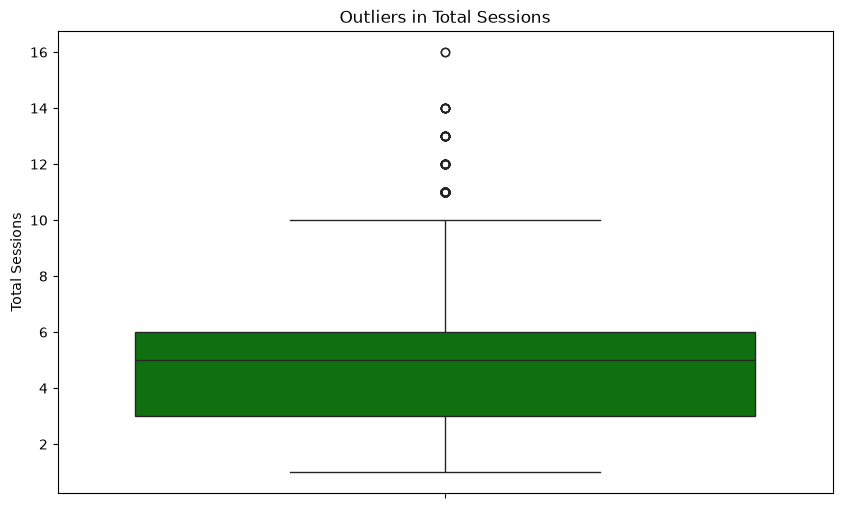

In [57]:
# Outlier Detection — Session Count
plt.figure(figsize=(10,6))
sns.boxplot(data=riders_ml, y="total_sessions", color="green")
plt.title("Outliers in Total Sessions")
plt.ylabel("Total Sessions")

plt.savefig(r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\Data/outliers_total_sessions.png", dpi=300, bbox_inches="tight")
plt.show()
